**Описание проекта: промышленность**

Чтобы оптимизировать производственные расходы, металлургический комбинат ООО «Так закаляем сталь» решил уменьшить потребление электроэнергии на этапе обработки стали. Вам предстоит построить модель, которая предскажет температуру стали.

Описание этапа обработки

Сталь обрабатывают в металлическом ковше вместимостью около 100 тонн. Чтобы ковш выдерживал высокие температуры, изнутри его облицовывают огнеупорным кирпичом. Расплавленную сталь заливают в ковш и подогревают до нужной температуры графитовыми электродами. Они установлены в крышке ковша. 

Из сплава выводится сера (десульфурация), добавлением примесей корректируется химический состав и отбираются пробы. Сталь легируют — изменяют её состав — подавая куски сплава из бункера для сыпучих материалов или проволоку через специальный трайб-аппарат (англ. tribe, «масса»).

Перед тем как первый раз ввести легирующие добавки, измеряют температуру стали и производят её химический анализ. Потом температуру на несколько минут повышают, добавляют легирующие материалы и продувают сплав инертным газом. Затем его перемешивают и снова проводят измерения. Такой цикл повторяется до достижения целевого химического состава и оптимальной температуры плавки.

Тогда расплавленная сталь отправляется на доводку металла или поступает в машину непрерывной разливки. Оттуда готовый продукт выходит в виде заготовок-слябов (англ. slab, «плита»).
Описание данных

Данные состоят из файлов, полученных из разных источников:

    data_arc_new.csv — данные об электродах;
    data_bulk_new.csv — данные о подаче сыпучих материалов (объём);
    data_bulk_time_new.csv — данные о подаче сыпучих материалов (время);
    data_gas_new.csv — данные о продувке сплава газом;
    data_temp_new.csv — результаты измерения температуры;
    data_wire_new.csv — данные о проволочных материалах (объём);
    data_wire_time_new.csv — данные о проволочных материалах (время).
    
Во всех файлах столбец key содержит номер партии. В файлах может быть несколько строк с одинаковым значением key: они соответствуют разным итерациям обработки.

## Исследовательский анализ

### Импорт библиотек

In [2]:
import pandas as pd

### Знакомство с данными

In [3]:
try:
    data_arc = pd.read_csv('/datasets/data_arc_new.csv')
    data_bulk = pd.read_csv('/datasets/data_bulk_new.csv')
    data_bulk_time = pd.read_csv('/datasets/data_bulk_time_new.csv')
    data_gas = pd.read_csv('/datasets/data_gas_new.csv')
    data_temp = pd.read_csv('/datasets/data_temp_new.csv')
    data_wire = pd.read_csv('/datasets/data_wire_new.csv')
    data_wire_time = pd.read_csv('/datasets/data_wire_time_new.csv')
except:
    data_arc = pd.read_csv('C:/Users/azath/OneDrive/Рабочий стол/Проект/data_arc_new.csv')
    data_bulk = pd.read_csv('C:/Users/azath/OneDrive/Рабочий стол/Проект/data_bulk_new.csv')
    data_bulk_time = pd.read_csv('C:/Users/azath/OneDrive/Рабочий стол/Проект/data_bulk_time_new.csv')
    data_gas = pd.read_csv('C:/Users/azath/OneDrive/Рабочий стол/Проект/data_gas_new.csv')
    data_temp = pd.read_csv('C:/Users/azath/OneDrive/Рабочий стол/Проект/data_temp_new.csv')
    data_wire = pd.read_csv('C:/Users/azath/OneDrive/Рабочий стол/Проект/data_wire_new.csv')
    data_wire_time = pd.read_csv('C:/Users/azath/OneDrive/Рабочий стол/Проект/data_wire_time_new.csv')

#### Таблица data_arc

In [4]:
data_arc.head(20)

,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691
5,2,2019-05-03 11:34:14,2019-05-03 11:36:31,0.381124,0.220351
6,2,2019-05-03 11:38:50,2019-05-03 11:44:28,0.261665,0.205527
7,2,2019-05-03 11:46:19,2019-05-03 11:48:25,0.710297,0.484962
8,2,2019-05-03 11:49:48,2019-05-03 11:53:18,0.786322,0.542517
9,3,2019-05-03 12:06:54,2019-05-03 12:11:34,1.101678,0.820856


Сразу бросаются в глаза названия столбцов. Написаны на русском, через заглавные буквы и с пробелами. В дальнейшем необходимо будет привести в надлежащий вид.

Начало и конец нагрева дугой еще понятно, а вот Активная и Реактивная мощность уже нет. Учитывая, что эти столбцы, судя по заданию будут являтся ключевыми, необходимо дать объяснения данным терминам. Вот что первым нашлось в интернете:

**Активная мощность**

Эта мощность, потребляемая нагрузкой типа обычного сопротивления. Как правило, это все нагревательные приборы (бойлеры, обычные электроплитки, электро калориферы и т.п.). Потребляемая мощность этих приборов полностью активная. В этих приборах электрическая энергия безвозвратно и полностью преобразуется в другой вид энергии (тепловую и другие).

Активная мощность обозначается буквой P и измеряется в ваттах (Вт).

Величина активной мощности, потребляемой такими приборами считается просто — умножением напряжения в розетке на ток, протекающей в цепи включенного нагревательного прибора:

P = U * I

Тут всё просто. Нагрузка пассивна, постоянна, никаких неожиданностей.

Замечу, что в цепях постоянного тока существует только активная мощность, поскольку значение мгновенной и средней мощности там совпадают.

**Реактивная мощность**

Если включить в сеть переменного тока не нагревательный прибор, а, например, электромагнит, то помимо активной, в цепи возникает реактивная энергия, которая с частотой переменного тока то потребляется прибором, то возвращается обратно в сеть. Эта энергия переносится от источника к электромагниту и обратно дважды за период, каждую четверть периода меняя направление.

Это происходит из-за того, что при потреблении электроэнергии, например, обмоткой магнита, каждый полупериод в нём происходит временное запасание энергии в магнитном поле катушки, и последующая отдача её назад, из-за чего происходит рассинхронизация синусоид величин напряжения и тока в сети.

Изменения тока в цепи отстаёт от соответствующих синусоидальных изменений напряжения. Такое поведение присуще любой т.н. индуктивной нагрузке (трансформаторы, электродвигатели, дроссели, электромагниты).

Помимо индуктивной нагрузки существует емкостная (различные электронные устройства с конденсаторами, как накопителями энергии, например, в импульсном блоке питания), в которой ток, наоборот, опережает напряжение за счёт временного накопления энергии конденсаторами и последующей отдачи её назад. И в том и в другом случае в цепи помимо активной возникает реактивная энергия.

Вред реактивной энергии в электроэнергетике очевиден — она никак не используется, но шляется туда-сюда по проводам, дополнительно нагружая их. Кроме того, при таком «шлянии» эта энергия ещё и частично теряется, преобразуясь в активную энергию при нагреве проводов. Однако в радиотехнике реактивная мощность может быть и полезной (например, в колебательных контурах).

Реактивная мощность обозначается буквой Q и измеряется в вольт-амперах реактивных (вар).

Для вычисления доли реактивной мощности применяется формула:

Q = U * I * sin φ, где:
sin φ — коэффициент мощности, показывающий, какую долю полной мощности составляет реактивная мощность.

Для вычисления активной мощности в сетях с реактивной составляющей применяется формула:

P = U * I * cos φ, где:
cos φ — коэффициент мощности, показывающий, какую долю полной мощности составляет активная мощность.

Коэффициенты мощностей разных приборов обычно указываются в паспортах на них.

**Полная мощность**

Полная мощность — эта вся мощность, и активная и неактивная.

Полная мощность обозначается буквой S и измеряется в вольт-амперах (ВА).

В случае линейной (равномерной на протяжении периода) нагрузки полная мощность равна корню квадратному из суммы квадратов активной и реактивной мощности. В этом случае неактивная мощность полностью состоит из реактивной составляющей.

S = √(P² + Q²)

То есть, полная мощность получается не лобовым сложением активной и неактивной частей, а по закону прямоугольного треугольника:

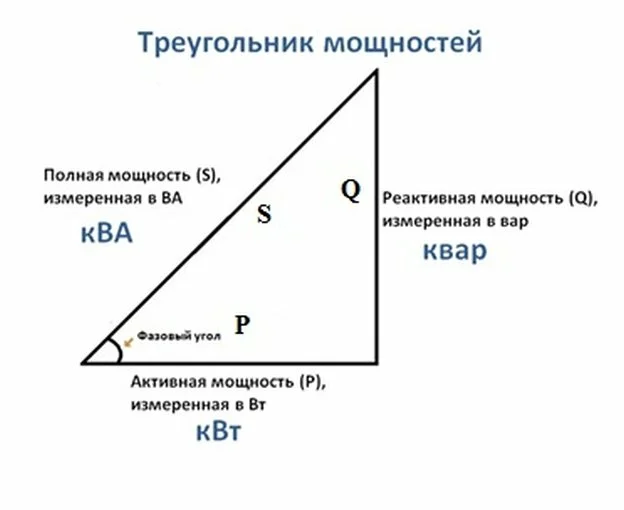

In [5]:
data_arc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   key                   14876 non-null  int64  
 1   Начало нагрева дугой  14876 non-null  object 
 2   Конец нагрева дугой   14876 non-null  object 
 3   Активная мощность     14876 non-null  float64
 4   Реактивная мощность   14876 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 581.2+ KB


In [16]:
data_arc.isna().sum()

key                     0
Начало нагрева дугой    0
Конец нагрева дугой     0
Активная мощность       0
Реактивная мощность     0
dtype: int64

Столбцы Начала и конца нагрева дугой имеют тип object нужно будет перевести в datetime. 

Посмотрим на количество партий расплава. 

In [17]:
len(data_arc['key'].unique())

3214

Взглянем на гистограммы. 

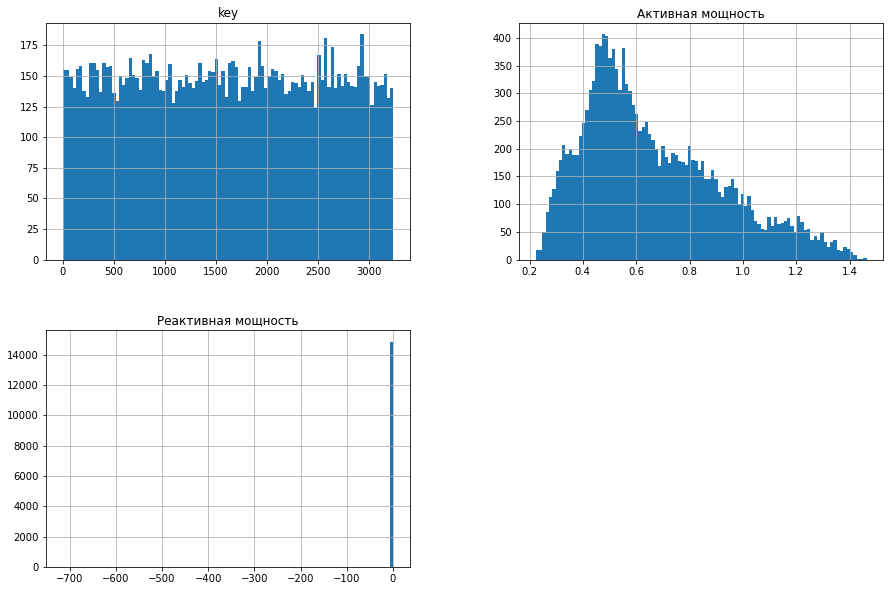

In [18]:
data_arc.hist(bins=100, figsize=(15,10));

Судя по гистограммам, в столбце "реактивная мощность" явно присутствуют выбросы. Остальные вроде более-менее выглядят нормальными. 

Посмотрим на числовое описание.

In [8]:
data_arc.describe().T

,count,mean,std,min,25%,50%,75%,max
key,14876.0,1615.220422,934.571502,1.000000,806.000000,1617.000000,2429.000000,3241.000000
Активная мощность,14876.0,0.662752,0.258885,0.223120,0.467115,0.599587,0.830070,1.463773
Реактивная мощность,14876.0,0.438986,5.873485,-715.479924,0.337175,0.441639,0.608201,1.270284


Посмотрим на диапозон до 0 в столбце Реактивная мощность.

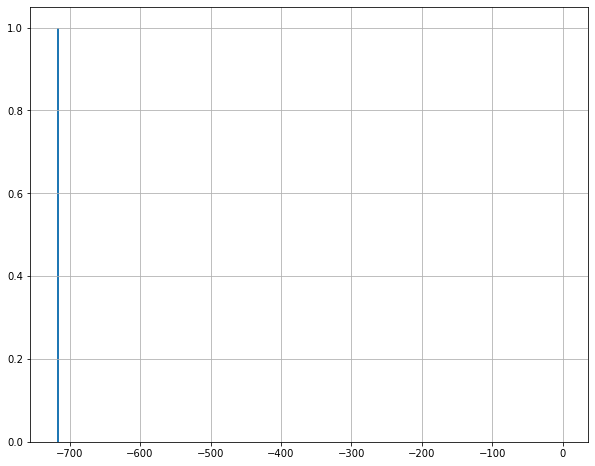

In [9]:
data_arc['Реактивная мощность'].hist(bins=300, figsize=(10,8), range=(-720, 0));

Всего 1 случай. Посмотрим на остальные значения.

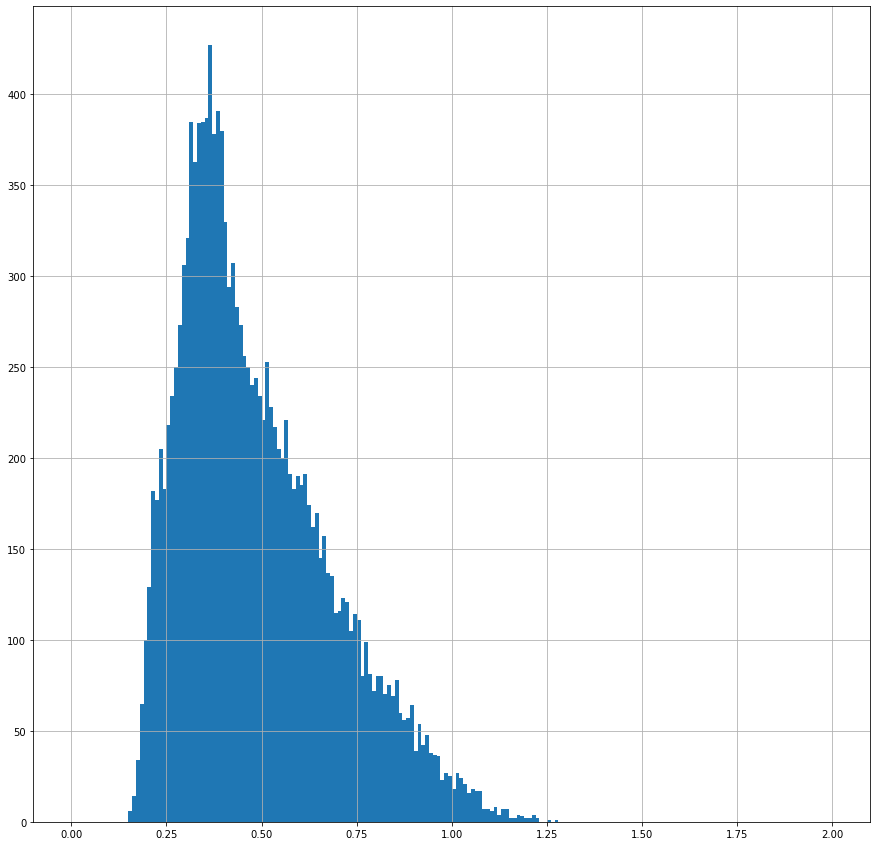

In [10]:
data_arc['Реактивная мощность'].hist(bins=200, figsize=(15,15), range=(0,2));

При предобработке нужно будет избавится от данного выброса. 

In [27]:
data_arc.duplicated().sum()

0

Дубликатов не обнаружено.

**Подитог:**

    - Пропуски и дубликаты в данной таблице отсутствуют;
    - названия столбцов написаны на русском, через заглавные буквы и с пробелами. В дальнейшем необходимо будет привести в надлежащий вид;
    - в столбце реактивная мощность присутствует выброс.

#### Таблица data_bulk

Таблица data_bulk - данные о подаче сыпучих материалов (объём)

In [11]:
data_bulk.head(20)

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,150.0,154.0
1,2,NaN,NaN,NaN,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,149.0,154.0
2,3,NaN,NaN,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.0,NaN,152.0,153.0
3,4,NaN,NaN,NaN,81.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207.0,NaN,153.0,154.0
4,5,NaN,NaN,NaN,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.0,NaN,151.0,152.0
5,6,NaN,NaN,NaN,117.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,NaN,201.0,154.0
6,7,NaN,NaN,NaN,117.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,NaN,152.0,154.0
7,8,NaN,NaN,NaN,99.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,410.0,NaN,252.0,153.0
8,9,NaN,NaN,NaN,117.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,107.0,NaN,99.0,203.0
9,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.0,NaN,102.0,204.0


В данной таблице, столбец "Bulk" с номером - означает определенный легирующий элемент, который подается в ковш с расплавленным металлом. Множественные пропуски наверное можно смело заменить 0, т.е. данный материал не подавалося в данной партии. 

In [12]:
data_bulk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   Bulk 1   252 non-null    float64
 2   Bulk 2   22 non-null     float64
 3   Bulk 3   1298 non-null   float64
 4   Bulk 4   1014 non-null   float64
 5   Bulk 5   77 non-null     float64
 6   Bulk 6   576 non-null    float64
 7   Bulk 7   25 non-null     float64
 8   Bulk 8   1 non-null      float64
 9   Bulk 9   19 non-null     float64
 10  Bulk 10  176 non-null    float64
 11  Bulk 11  177 non-null    float64
 12  Bulk 12  2450 non-null   float64
 13  Bulk 13  18 non-null     float64
 14  Bulk 14  2806 non-null   float64
 15  Bulk 15  2248 non-null   float64
dtypes: float64(15), int64(1)
memory usage: 391.2 KB


In [29]:
len(data_bulk['key'].unique())

3129

Типы данных соответствуют столбцам. Менять необходимости нет. Единственное, что смущает - это количество строк. В предыдущей таблице было 3214 партий стали, здесь же 3129. Похоже не все партии стали подвергаются легированию? Или не все партии подвергаются легированию сыпучими материалами? Отсюда возникает вопрос, рассматривать ли те партии, которые не подвергаются легировани? 

Также есть столбец, в котором только одна запись. Есть столбцы в которых только 19-25 записей, т.е. меньше 1 %.  Что с ними делать?

In [45]:
data_bulk.isna().sum()

key           0
Bulk 1     2877
Bulk 2     3107
Bulk 3     1831
Bulk 4     2115
Bulk 5     3052
Bulk 6     2553
Bulk 7     3104
Bulk 8     3128
Bulk 9     3110
Bulk 10    2953
Bulk 11    2952
Bulk 12     679
Bulk 13    3111
Bulk 14     323
Bulk 15     881
dtype: int64

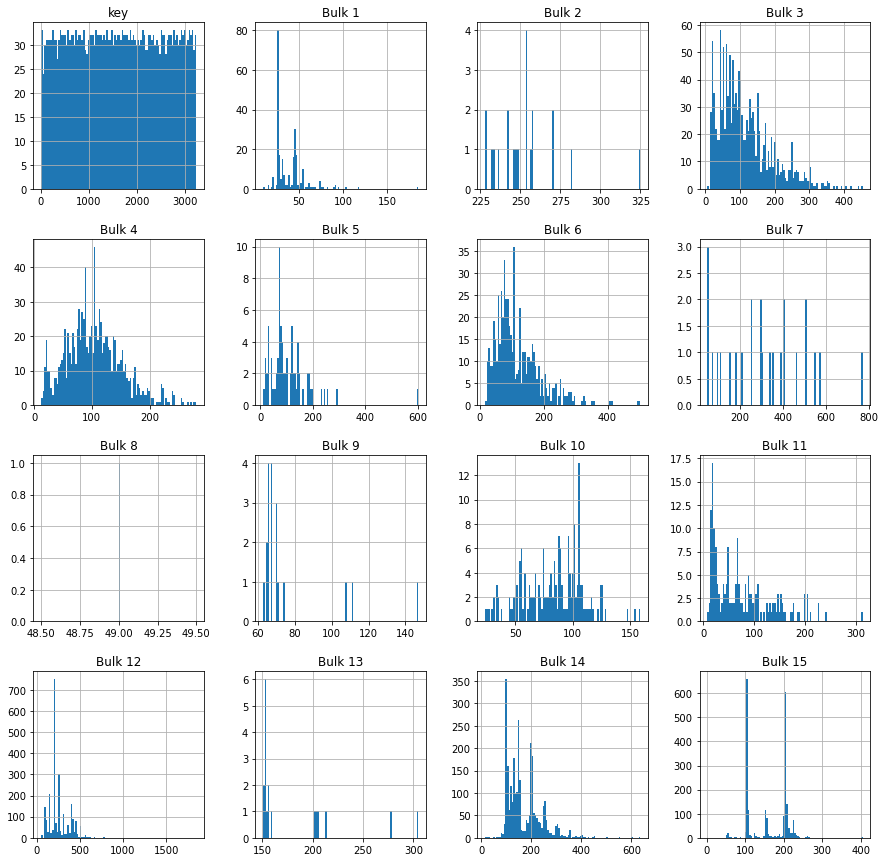

In [46]:
data_bulk.hist(bins=100, figsize=(15,15));

По гистограммам ничего внятного сказать не возможно.

In [51]:
data_bulk.describe().T

,count,mean,std,min,25%,50%,75%,max
key,3129.0,1624.383509,933.337642,1.0,816.00,1622.0,2431.00,3241.0
Bulk 1,252.0,39.242063,18.277654,10.0,27.00,31.0,46.00,185.0
Bulk 2,22.0,253.045455,21.180578,228.0,242.00,251.5,257.75,325.0
Bulk 3,1298.0,113.879045,75.483494,6.0,58.00,97.5,152.00,454.0
Bulk 4,1014.0,104.394477,48.184126,12.0,72.00,102.0,133.00,281.0
Bulk 5,77.0,107.025974,81.790646,11.0,70.00,86.0,132.00,603.0
Bulk 6,576.0,118.925347,72.057776,17.0,69.75,100.0,157.00,503.0
Bulk 7,25.0,305.600000,191.022904,47.0,155.00,298.0,406.00,772.0
Bulk 8,1.0,49.000000,NaN,49.0,49.00,49.0,49.00,49.0
Bulk 9,19.0,76.315789,21.720581,63.0,66.00,68.0,70.50,147.0


In [47]:
data_bulk.duplicated().sum()

0

**Подитог:**

    - дубликатов нет;
    - необходимо заменить пустые значения нулями;
    - необходимо разобраться со столбцами, в которых мало записей;
    - привести названия столбцов в правильный вид.

#### Таблица data_bulk_time

В таблице data_bulk_time - данные о подаче сыпучих материалов (время).

In [41]:
data_bulk_time.head(10)

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,2019-05-03 11:28:48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 11:24:31,NaN,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2,NaN,NaN,NaN,2019-05-03 11:36:50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 11:53:30,NaN,2019-05-03 11:48:37,2019-05-03 11:44:39
2,3,NaN,NaN,NaN,2019-05-03 12:32:39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 12:27:13,NaN,2019-05-03 12:21:01,2019-05-03 12:16:16
3,4,NaN,NaN,NaN,2019-05-03 12:43:22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 12:58:00,NaN,2019-05-03 12:51:11,2019-05-03 12:46:36
4,5,NaN,NaN,NaN,2019-05-03 13:30:47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 13:30:47,NaN,2019-05-03 13:34:12,2019-05-03 13:30:47
5,6,NaN,NaN,NaN,2019-05-03 13:57:27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 13:48:52,NaN,2019-05-03 14:09:42,2019-05-03 14:03:15
6,7,NaN,NaN,NaN,2019-05-03 14:18:58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 14:41:26,NaN,2019-05-03 14:30:50,2019-05-03 14:27:16
7,8,NaN,NaN,NaN,2019-05-03 15:17:58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 15:17:58,NaN,2019-05-03 15:13:18,2019-05-03 15:05:33
8,9,NaN,NaN,NaN,2019-05-03 16:03:08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 16:03:08,NaN,2019-05-03 16:00:16,2019-05-03 15:52:39
9,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 16:38:11,NaN,2019-05-03 16:34:24,2019-05-03 16:29:56


In [39]:
data_bulk_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   key      3129 non-null   int64 
 1   Bulk 1   252 non-null    object
 2   Bulk 2   22 non-null     object
 3   Bulk 3   1298 non-null   object
 4   Bulk 4   1014 non-null   object
 5   Bulk 5   77 non-null     object
 6   Bulk 6   576 non-null    object
 7   Bulk 7   25 non-null     object
 8   Bulk 8   1 non-null      object
 9   Bulk 9   19 non-null     object
 10  Bulk 10  176 non-null    object
 11  Bulk 11  177 non-null    object
 12  Bulk 12  2450 non-null   object
 13  Bulk 13  18 non-null     object
 14  Bulk 14  2806 non-null   object
 15  Bulk 15  2248 non-null   object
dtypes: int64(1), object(15)
memory usage: 391.2+ KB


В таблице указано время засыпки легирующих элементов, но столбцы имеют тип object, нужно будет менять. По аналогии с предыдущей таблицей имеются пропуски. Посмотрим на сколько они совпадают.

In [43]:
display(data_bulk_time.isna().sum())
display(data_bulk.isna().sum())

key           0
Bulk 1     2877
Bulk 2     3107
Bulk 3     1831
Bulk 4     2115
Bulk 5     3052
Bulk 6     2553
Bulk 7     3104
Bulk 8     3128
Bulk 9     3110
Bulk 10    2953
Bulk 11    2952
Bulk 12     679
Bulk 13    3111
Bulk 14     323
Bulk 15     881
dtype: int64

key           0
Bulk 1     2877
Bulk 2     3107
Bulk 3     1831
Bulk 4     2115
Bulk 5     3052
Bulk 6     2553
Bulk 7     3104
Bulk 8     3128
Bulk 9     3110
Bulk 10    2953
Bulk 11    2952
Bulk 12     679
Bulk 13    3111
Bulk 14     323
Bulk 15     881
dtype: int64

Расхождений нет, значит все норм.

**Подитог:**
    
    - необходимо изменить тип столбцов;
    - аналогично привести названия столбцов в правильный вид.

#### Таблица data_gas

Таблица data_gas - данные о продувке сплава газом.

In [53]:
data_gas.head(10)

,key,Газ 1
0,1,29.749986
1,2,12.555561
2,3,28.554793
3,4,18.841219
4,5,5.413692
5,6,11.273392
6,7,9.836267
7,8,15.171553
8,9,8.216623
9,10,6.529891


In [15]:
data_gas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3239 non-null   int64  
 1   Газ 1   3239 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 50.7 KB


In [54]:
data_gas.isna().sum()

key      0
Газ 1    0
dtype: int64

Пропусков нет. Типы столбцов соыпадают.

In [23]:
data_gas.describe().T

,count,mean,std,min,25%,50%,75%,max
key,3239.0,1621.861377,935.386334,1.000000,812.500000,1622.000000,2431.500000,3241.00000
Газ 1,3239.0,11.002062,6.220327,0.008399,7.043089,9.836267,13.769915,77.99504


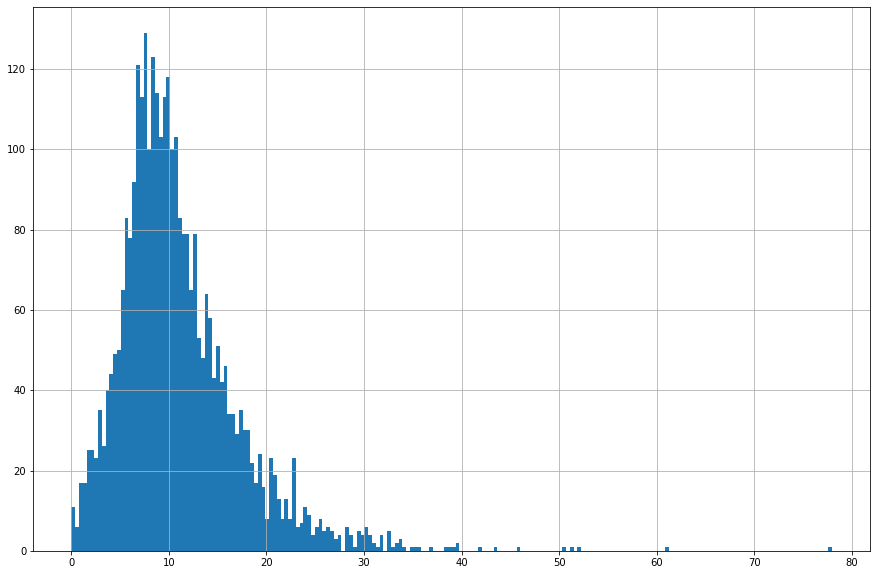

In [56]:
data_gas['Газ 1'].hist(bins=200, figsize=(15,10));

Судя по гистограмме и числовому описанию в столбце присутствуют выбросы, но насколько данная таблица актуальна...пока не понятно. Надо будет смотреть на корреляцию газа и температуры.

#### Таблица data_temp

Таблица data_temp — результаты измерения температуры. Как понимаю, целевой признак для будущей модели.

In [16]:
data_temp.head(20)

,key,Время замера,Температура
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0
3,1,2019-05-03 11:18:04,1601.0
4,1,2019-05-03 11:25:59,1606.0
5,1,2019-05-03 11:30:38,1613.0
6,2,2019-05-03 11:34:04,1581.0
7,2,2019-05-03 11:38:40,1577.0
8,2,2019-05-03 11:46:09,1589.0
9,2,2019-05-03 11:49:38,1604.0


На каждую партию приходится по несколько измерений. Судя по описанию, последнее измерение является достижением целевого химического состава и оптимальной температуры плавки. 

Похоже у всех таблиц одинаковые проблемы, названия столбцов и даты с типом object.

In [19]:
data_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18092 entries, 0 to 18091
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   key           18092 non-null  int64  
 1   Время замера  18092 non-null  object 
 2   Температура   14665 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 424.2+ KB


In [26]:
len(data_temp['Температура'].unique())

173

In [58]:
data_temp.duplicated().sum() 

0

Дубликатов не обнаружено, всего 173 "уникальных" температур.

In [29]:
data_temp.describe().T

,count,mean,std,min,25%,50%,75%,max
key,18092.0,1616.460977,934.641385,1.0,807.75,1618.0,2429.0,3241.0
Температура,14665.0,1590.722741,20.394381,1191.0,1580.00,1590.0,1599.0,1705.0


<AxesSubplot:>

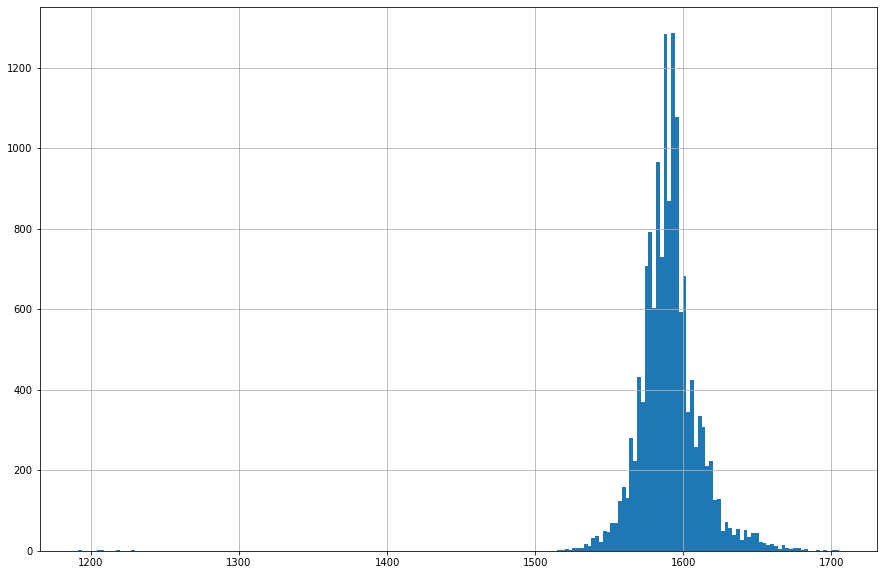

In [57]:
data_temp['Температура'].hist(bins=200, figsize=(15,10))

Судя по гистограмме, присутствуют выбросы в районе 1200 С. Но понять это можно будет только после отборов последних измерений от каждой партии(если конечно ход моих мыслей верен).

#### Таблица data_wire

Таблица data_wire  — данные о проволочных материалах (объём).

In [59]:
data_wire.head(20)

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,60.059998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,96.052315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,91.160157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,89.063515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,89.238236,9.114560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,6,99.109917,9.114560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,7,98.061600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8,155.282394,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,9,113.393279,9.143681,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10,81.244796,12.376000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
data_wire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3081 non-null   int64  
 1   Wire 1  3055 non-null   float64
 2   Wire 2  1079 non-null   float64
 3   Wire 3  63 non-null     float64
 4   Wire 4  14 non-null     float64
 5   Wire 5  1 non-null      float64
 6   Wire 6  73 non-null     float64
 7   Wire 7  11 non-null     float64
 8   Wire 8  19 non-null     float64
 9   Wire 9  29 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 240.8 KB


In [61]:
data_wire.duplicated().sum()

0

Данная таблица аналогична таблице data_bulk. Показывает количество подаваемого легирующего элемента, но проволочного типа. Ситуация и возникающие вопросы схожи с таблицей data_bulk. Нужно будет после предобработки посмотреть на них и сравнить по номерам партий. Если будет мало случаев по каким либо легирующим элементам, то использовать их при обучении модели будет не корректно.

#### Таблица data_wire_time

In [29]:
data_wire_time.head(20)

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,2019-05-03 11:06:19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2019-05-03 11:36:50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2019-05-03 12:11:46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2019-05-03 12:43:22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2019-05-03 13:20:44,2019-05-03 13:15:34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,6,2019-05-03 13:57:27,2019-05-03 13:48:52,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,7,2019-05-03 14:18:58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8,2019-05-03 15:01:30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,9,2019-05-03 15:45:44,2019-05-03 15:39:37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10,2019-05-03 16:27:00,2019-05-03 16:22:36,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
data_wire_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   key     3081 non-null   int64 
 1   Wire 1  3055 non-null   object
 2   Wire 2  1079 non-null   object
 3   Wire 3  63 non-null     object
 4   Wire 4  14 non-null     object
 5   Wire 5  1 non-null      object
 6   Wire 6  73 non-null     object
 7   Wire 7  11 non-null     object
 8   Wire 8  19 non-null     object
 9   Wire 9  29 non-null     object
dtypes: int64(1), object(9)
memory usage: 240.8+ KB


In [62]:
data_wire_time.duplicated().sum()

0

Все проблемы аналогичны таблице data_bulk_time. 

## План дальнейших действий

Думаю, что необходимо: 

       - Провести предобработку данных;
       - объединить таблицы по номеру партии;
       - дополнить исследовательский анализ с объединенными данными(хочу посмотреть на корреляции, увидеть, что лишнее);
       - подготовить данные к обучению модели;
       - обучение моделей;
       - отчет.